**Objetivo**: Implementar e avaliar a arquitetura PCN (Point Completion Network) para a tarefa de completação de nuvens de pontos 3D. Esse modelo deve ser de baseline para esta tarefa.
**Artigo de referência**: [PCN: Point Completion Network](https://arxiv.org/pdf/1808.00671)

## Dataset

O dataset utilizado é o **ShapeNet**, contendo pares de nuvens de pontos parciais (entrada) e completas (ground truth) de diferentes categorias de objetos tridimensionais (como aviões, carros, cadeiras, etc.).

## Arquitetura PCN

Treinamos e avaliamos a seguinte configuração da arquitetura PCN:
- **PCN padrão**: Configuração padrão descrita no artigo original.

## Configurações de treinamento

As configurações de treinamento foram carregadas dos arquivos JSON de configuração para ambas as versões:

In [6]:
import json
import pandas as pd
from pathlib import Path

rows = []
for name in ["pcn"]:
    base_dir = Path.cwd().parent 
    path = base_dir / Path(f"configs/{name}.json")
    if path.exists():
        with open(path) as f:
            cfg = json.load(f)
        for k, v in cfg.items():
            rows.append({"Configuração": name, "Parâmetro": k, "Valor": v})

df_cfg = pd.DataFrame(rows)
if not df_cfg.empty:
    df_pivot = df_cfg.pivot(index="Parâmetro", columns="Configuração", values="Valor")
    display(df_pivot)
else:
    print("Nenhuma configuração encontrada em configs/")

Configuração,pcn
Parâmetro,
decay_rate,0.7
decay_step,50000
global_feat_dim,1024
gpu,0
grid_scale,0.05
grid_size,4
learning_rate,0.0001
log_dir,log
max_epoch,50


## Curvas de treinamento

In [ ]:
# %run training/train_pcn.py --config pcn

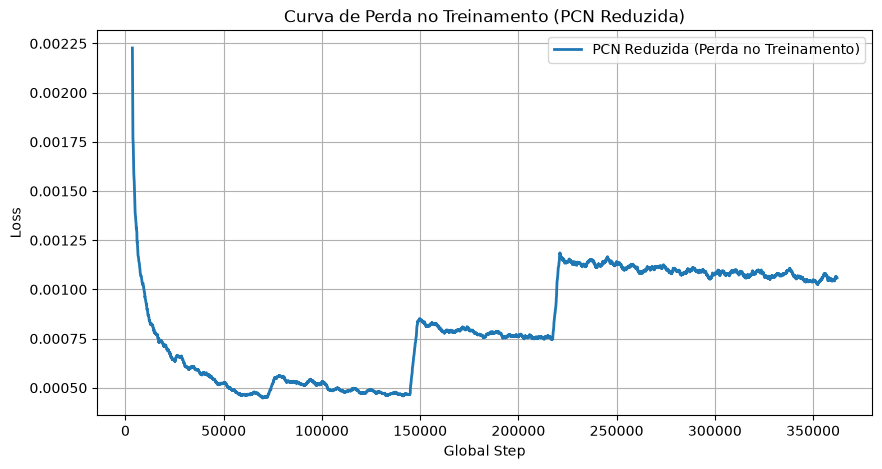

In [ ]:
from tensorboard.backend.event_processing import event_accumulator
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

run_dir = base_dir / Path("log/20260618_210722/train")
if run_dir.exists():
    try:
        ea = event_accumulator.EventAccumulator(str(run_dir))
        ea.Reload()
        
        loss_events = ea.Scalars("loss")
        steps = np.array([e.step for e in loss_events])
        losses = np.array([e.value for e in loss_events])
        
        window = 100
        if len(losses) > window:
            smooth_losses = np.convolve(losses, np.ones(window)/window, mode="valid")
            smooth_steps = steps[window-1:]
        else:
            smooth_losses = losses
            smooth_steps = steps
            
        plt.figure(figsize=(10, 5))
        plt.plot(smooth_steps, smooth_losses, label="PCN Reduzida (Perda no Treinamento)", linewidth=2)
        plt.title("Curva de Perda no Treinamento (PCN Reduzida)")
        plt.xlabel("Global Step")
        plt.ylabel("Loss")
        plt.grid(True)
        plt.legend()
        plt.show()
    except Exception as e:
        print("Erro ao ler logs do TensorBoard:", e)
else:
    print("Logs do TensorBoard para a run 20260618_210722 não encontrados ou vazios.")

## Avaliação quantitativa

In [ ]:
%run evaluation/evaluate_pcn.py --config pcn --run 20260618_210722

In [18]:
import json
import pandas as pd
from pathlib import Path

rows = []
evaluation_dir = base_dir / Path("evaluation")
runs = [
    ("pcn", "20260618_210722")
]

for config, run in runs:
    results_file = evaluation_dir / run / "results.json"
    if results_file.exists():
        with open(results_file) as f:
            results = json.load(f)
        rows.append({
            "Modelo": results["model_name"],
            "Epoch": results["epoch"],
            "Loss de Avaliação": results["eval_loss"],
            "CD Coarse": results["eval_coarse_cd"],
            "CD Dense": results["eval_dense_cd"]
        })

df_res = pd.DataFrame(rows)
df_res

,Modelo,Epoch,Loss de Avaliação,CD Coarse,CD Dense
0,pcn,50,0.001318,0.00089,0.000428


Parecem valores razoáveis.

### Avaliação por Classe de Objetos

Podemos também detalhar a avaliação analisando o desempenho do modelo para cada classe individual de objetos da base ShapeNet (utilizando os IDs de classe/synset correspondentes).

,Modelo,Classe ID,Classe,Amostras,Loss,CD Coarse,CD Dense
0,pcn,02691156,Avião,150,0.000508,0.000330,0.000177
1,pcn,02933112,Armário,150,0.001537,0.001100,0.000437
2,pcn,02958343,Carro,150,0.000859,0.000587,0.000272
3,pcn,03001627,Cadeira,150,0.001595,0.001072,0.000523
4,pcn,03636649,Luminária,150,0.001814,0.001174,0.000640
5,pcn,04256520,Sofá,150,0.001736,0.001178,0.000558
6,pcn,04379243,Mesa,150,0.001258,0.000873,0.000385
7,pcn,04530566,Barco,150,0.001237,0.000804,0.000433


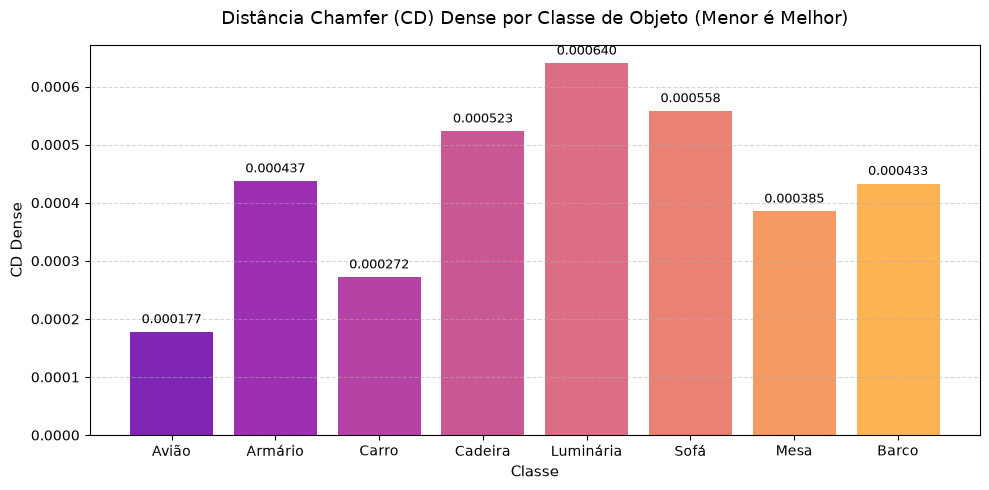

In [ ]:
class_names_pt = {
    "02691156": "Avião",
    "02933112": "Armário",
    "02958343": "Carro",
    "03001627": "Cadeira",
    "03636649": "Luminária",
    "04256520": "Sofá",
    "04379243": "Mesa",
    "04530566": "Barco"
}

class_rows = []
for config, run in runs:
    results_file = evaluation_dir / run / "results.json"
    if results_file.exists():
        with open(results_file) as f:
            results = json.load(f)
        
        class_results = results.get("class_results", {})
        for cid, metrics in class_results.items():
            class_name = class_names_pt.get(cid, cid)
            class_rows.append({
                "Modelo": results["model_name"],
                "Classe ID": cid,
                "Classe": class_name,
                "Amostras": metrics["count"],
                "Loss": metrics["loss"],
                "CD Coarse": metrics["coarse_cd"],
                "CD Dense": metrics["dense_cd"]
            })

df_class = pd.DataFrame(class_rows)
display(df_class)

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 5))
colors = plt.cm.plasma(np.linspace(0.2, 0.8, len(df_class)))
bars = plt.bar(df_class["Classe"], df_class["CD Dense"], color=colors, alpha=0.85, edgecolor='none')

plt.title("Distância Chamfer (CD) Dense por Classe de Objeto (Menor é Melhor)", fontsize=13, pad=15)
plt.ylabel("CD Dense", fontsize=11)
plt.xlabel("Classe", fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.00001, f"{yval:.6f}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

Os resultados coincidem com os resultados do artigo original.

## Exemplos de completamento de nuvem de pontos

Exibindo resultados visuais gerados por: 20260618_210722


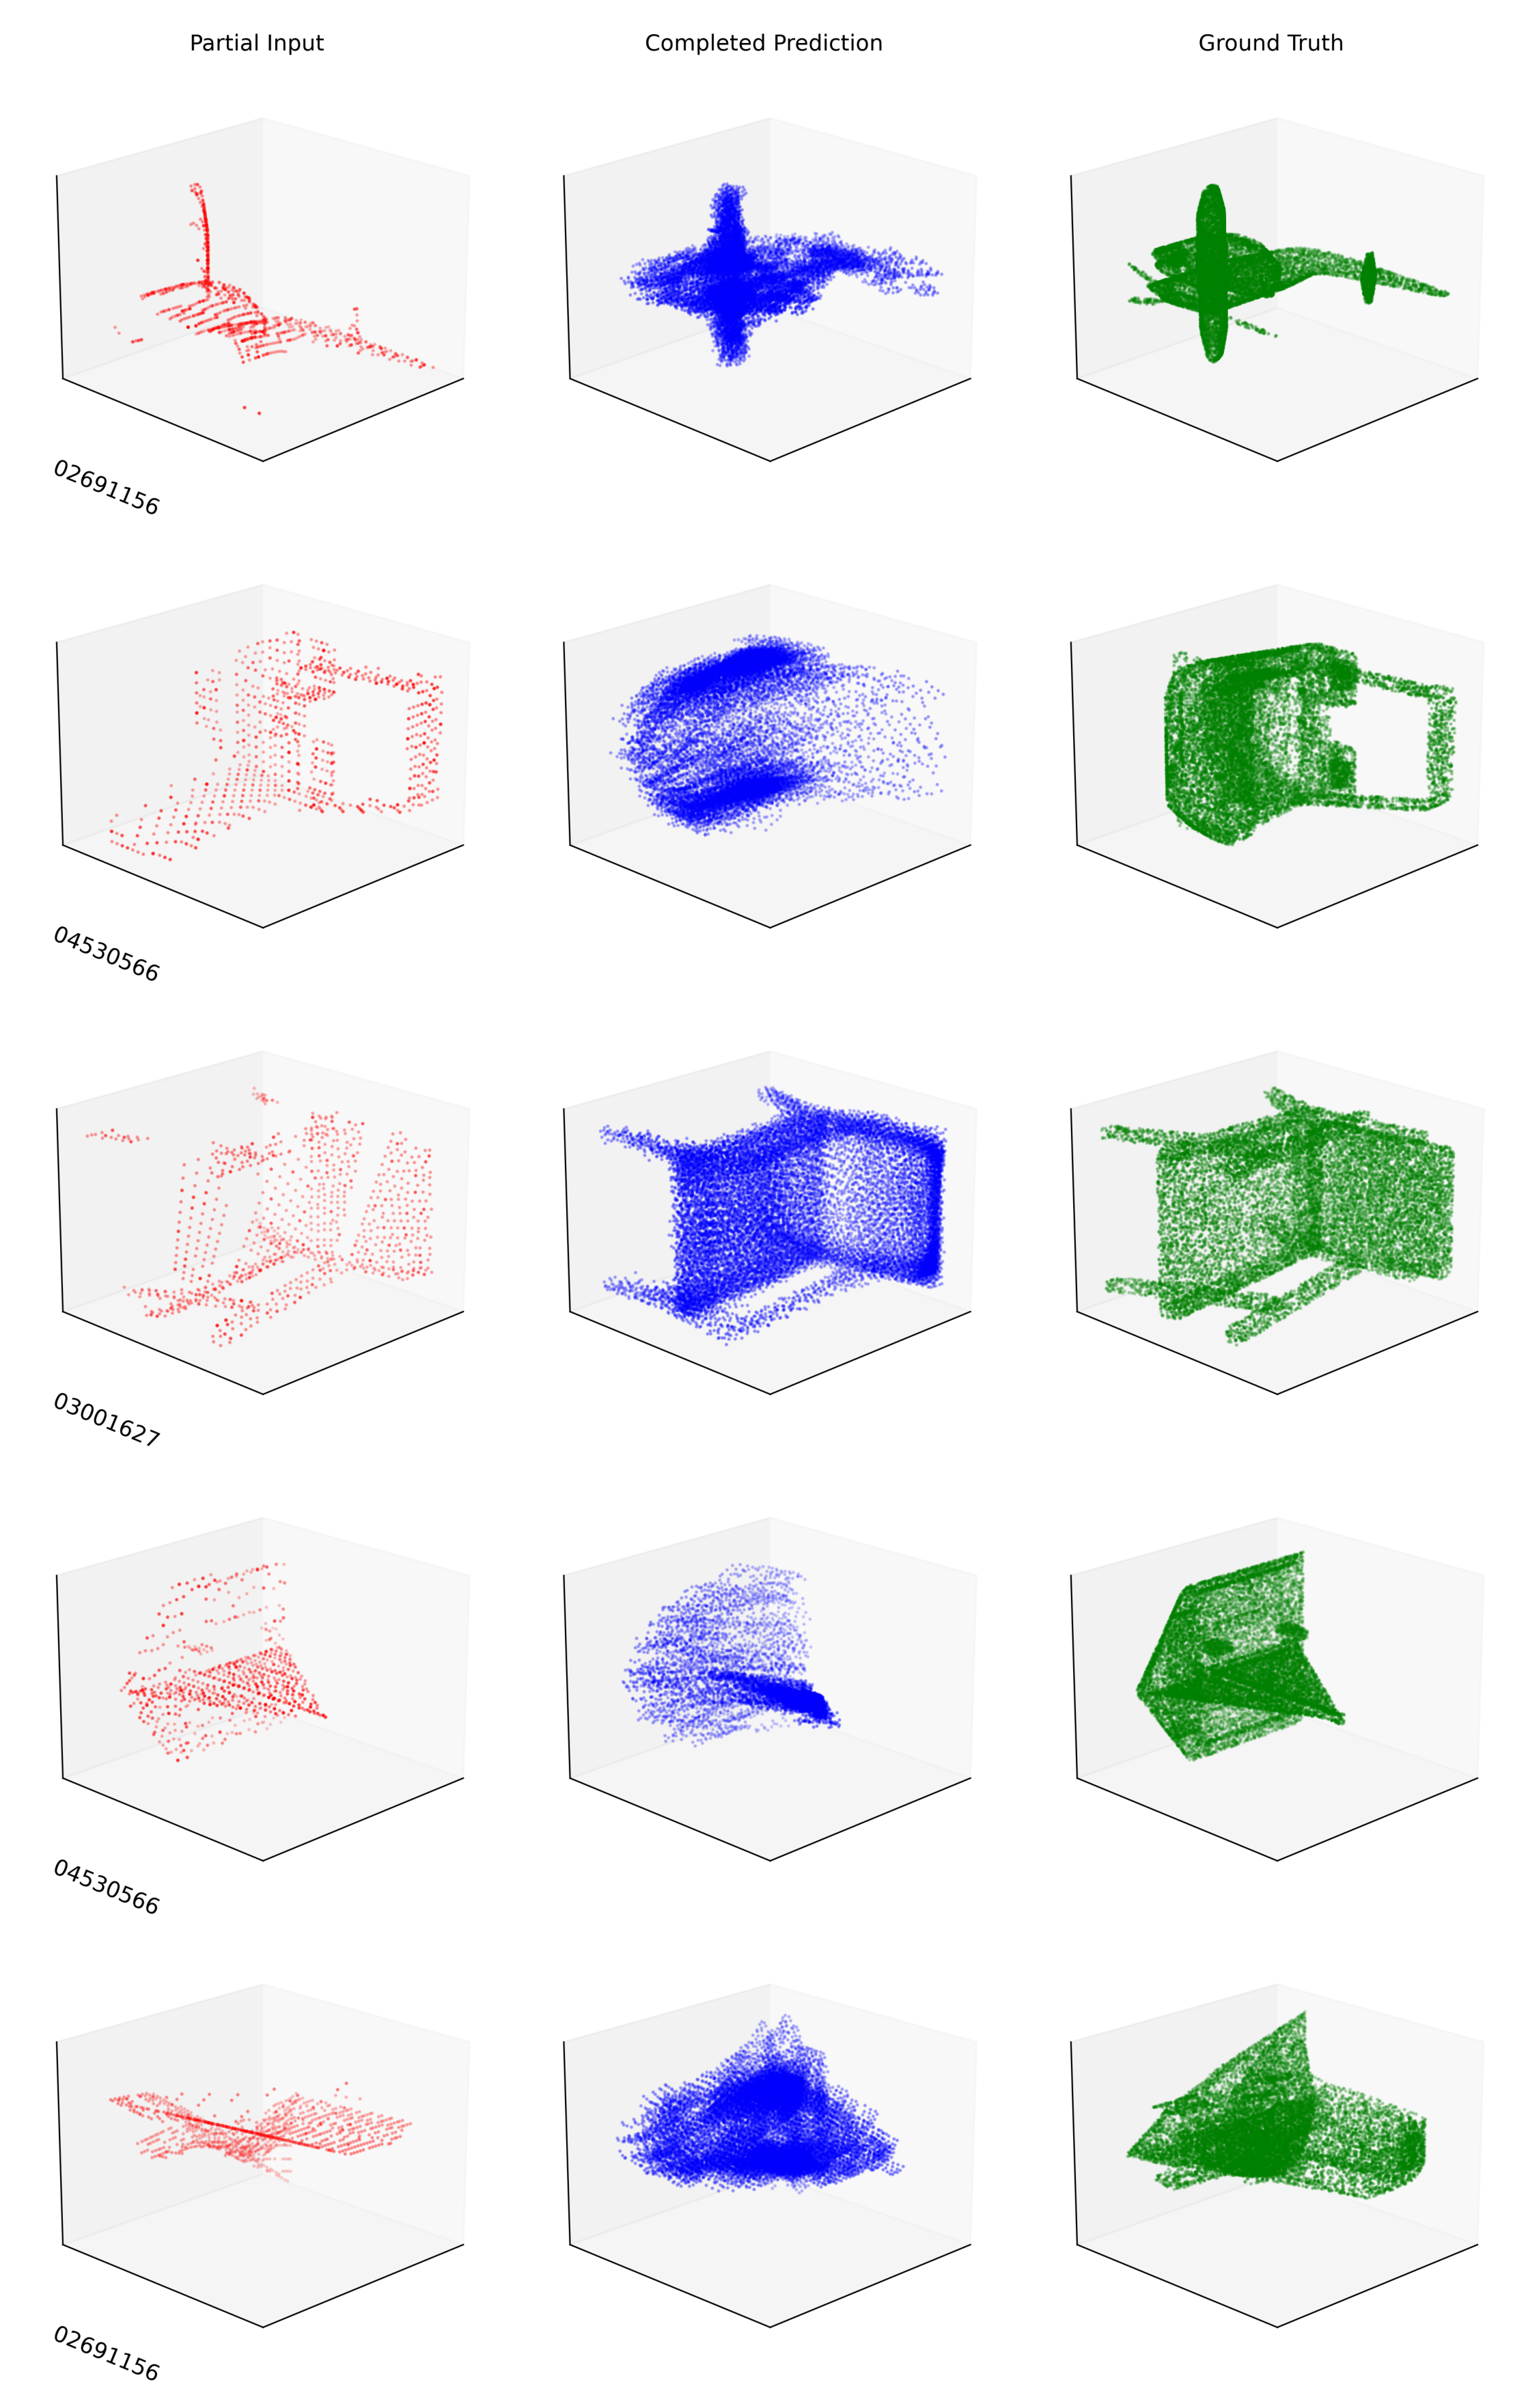

In [ ]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

img_paths = [
    base_dir / Path("evaluation/20260618_210722/test_examples/completion_examples.png")
]

for path in img_paths:
    if path.exists():
        print(f"Exibindo resultados visuais gerados por: {path.parent.parent.name}")
        img = Image.open(path)
        plt.figure(figsize=(10, 15), dpi=300)
        plt.imshow(img)
        plt.axis("off")
        plt.show()
        break

As reconstruções parecem razoáveis. \
Como observado nas figuras acimas, o modelo não lida bem com superfícies finas, um problema relatado pelo artigo original. A figura 2 exemplifica bem esse problema, exploremos melhor ela abaixo.

Exibindo imagem: 20260618_210722


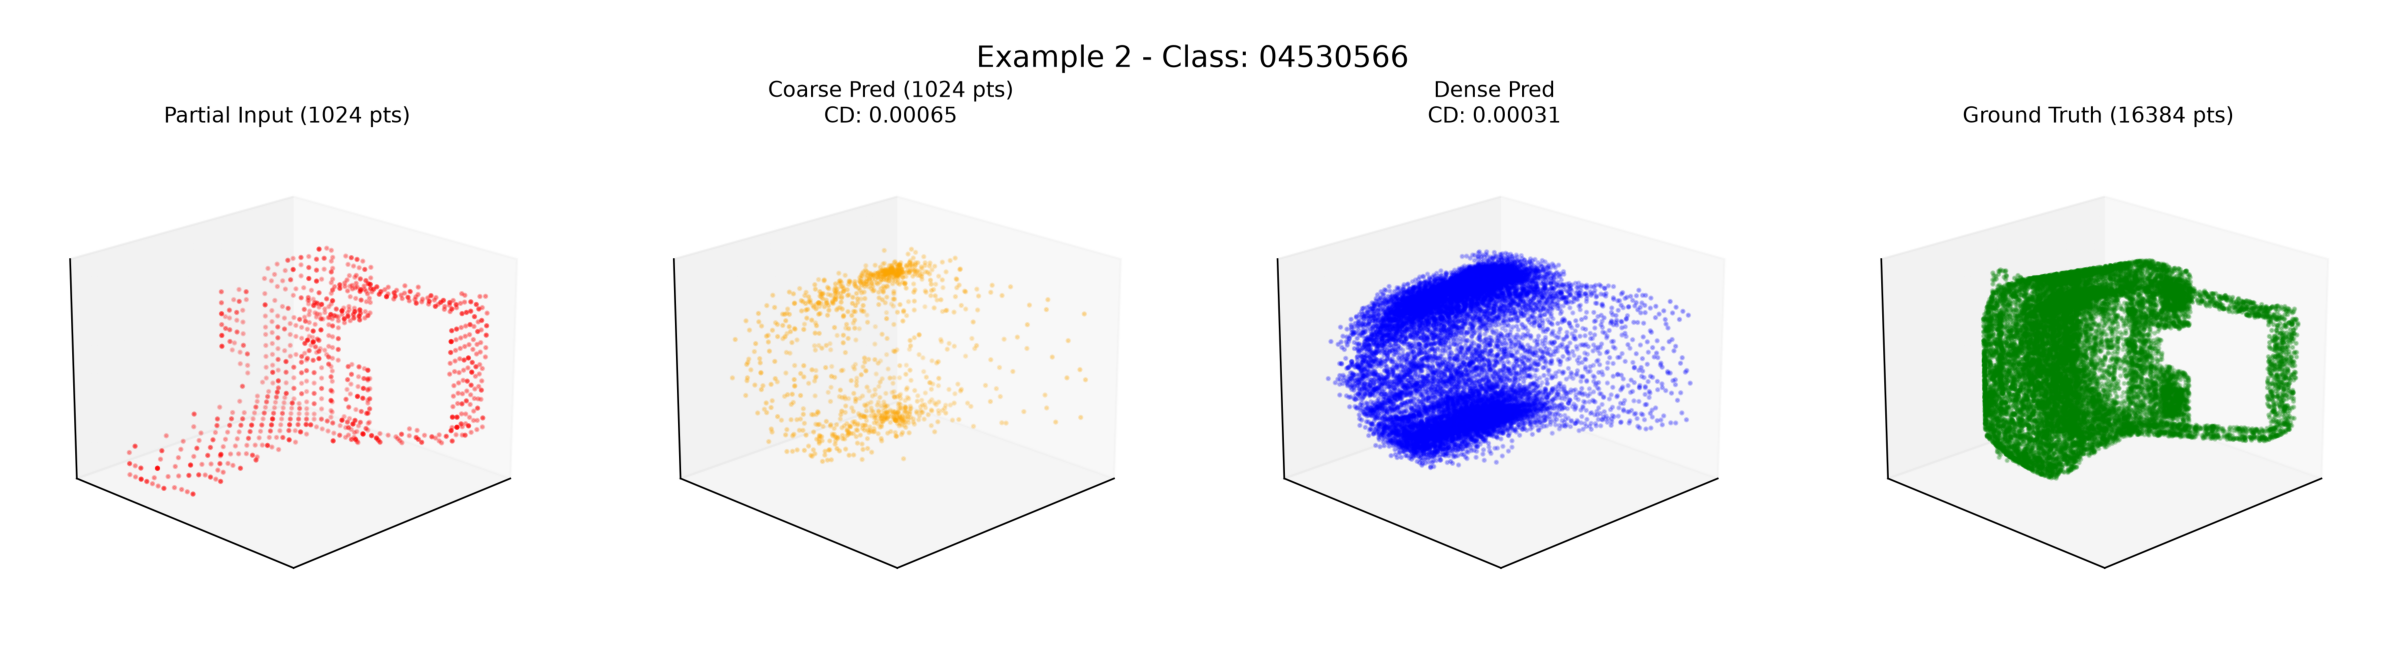

In [27]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

img_path = base_dir / Path("evaluation/20260618_210722/test_examples/example_2.png")

shown = False
if img_path.exists():
    print(f"Exibindo imagem: {path.parent.parent.name}")
    img = Image.open(img_path)
    plt.figure(figsize=(10, 15), dpi=300)
    plt.imshow(img)
    plt.axis("off")
    plt.show()
    shown = True

Nota-se que um espaço supostamente vazio da figura foi preenchido por pontos ainda durante a etapa da malha Coarse.

## Discussão final

O Point Completion Network (PCN) obteve resultados satisfatórios para a tarefa de completação de nuvens de pontos. 
Através do mecanismo de folding no decodificador denso, a rede conseguiu interpolar superfícies contínuas a partir do vetor de características global obtido pelo encoder PointNet, preenchendo as partes ocultas dos objetos de forma consistente.

**Possíveis melhorias para o PCN**:
1. Fazer pré-treino como autoencoder;
2. Explorar fragilidade do modelo: o modelo não consegue representar bem estruturas finas.

**Próximos passos**:
1. Pretendemos usar esse modelo como baseline e implementar uma outra arquitetura mais poderosa.